## **1. Load and import libraries**


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.tree import DecisionTreeClassifier, plot_tree

In [ ]:
df=pd.read_csv(
    '/content/drive/MyDrive/Colab Notebooks/Decision_Tree/[Data]-Student_Pass_Dataset.csv',
    names=['Điểm_Tốt_Nghiệp', 'Chứng_chỉ_Ielts', 'Cộng_Điểm_Dân_Tộc', 'Đậu_ĐH'],
    header=0
)

print("Original dataset:")
display(df)

Original dataset:


,Điểm_Tốt_Nghiệp,Chứng_chỉ_Ielts,Cộng_Điểm_Dân_Tộc,Đậu_ĐH
0,12.0,Không,Không,Không
1,14.5,Không,Có,Không
2,16.0,Không,Không,Không
3,18.0,Không,Có,Không
4,20.0,Có,Không,Có
5,22.0,Không,Không,Không
6,24.0,Có,Có,Có
7,26.0,Không,Không,Có


## **2. Encode the dataset**

In [ ]:
def encode_df(df):
# Encode categorical features and target
  df2 = df.copy()
  bin_map = {'Có': 0, 'Không': 1}
  df2['Chứng_chỉ_Ielts'] = df2['Chứng_chỉ_Ielts'].map(bin_map)
  df2["Cộng_Điểm_Dân_Tộc"] = df2['Cộng_Điểm_Dân_Tộc'].map(bin_map)
  df2['Đậu_ĐH'] = df2['Đậu_ĐH'].map(bin_map)
  return df2

df_encoded = encode_df(df)
print('Encoded data:')
display(df_encoded)

Encoded data:


,Điểm_Tốt_Nghiệp,Chứng_chỉ_Ielts,Cộng_Điểm_Dân_Tộc,Đậu_ĐH
0,12.0,1,1,1
1,14.5,1,0,1
2,16.0,1,1,1
3,18.0,1,0,1
4,20.0,0,1,0
5,22.0,1,1,1
6,24.0,0,0,0
7,26.0,1,1,0


## **3. Compute root entropy of the target**

In [ ]:
def entropy(probs):
  return -np.sum([p * np.log2(p) for p in probs if p > 0])

root_probs = df_encoded['Đậu_ĐH'].value_counts(normalize=True).sort_index().values
root_entropy = entropy(root_probs)
print(f"Root Entropy của Đậu_ĐH: {root_entropy:.4f}")

Root Entropy của Đậu_ĐH: 0.9544


## **4. Compute Information Gain for each feature**

In [ ]:
print("\nInformation Gain cho từng thuộc tính:")
features = ['Chứng_chỉ_Ielts', 'Điểm_Tốt_Nghiệp', 'Cộng_Điểm_Dân_Tộc']
for feature in features:
  print(f"\n - Thuộc tính: {feature}")
  vals = sorted(df_encoded[feature].unique())
  thresholds = [0.5] if feature in ['Chứng_chỉ_Ielts','Cộng_Điểm_Dân_Tộc'] \
                     else [(vals[i] + vals[i+1])/2 for i in range(len(vals) - 1)]
  best_gain = -1
  best_thr = None

  for thr in thresholds:
    left = df_encoded[df_encoded[feature] <= thr]['Đậu_ĐH']
    right= df_encoded[df_encoded[feature] > thr]['Đậu_ĐH']
    pL, pR = left.value_counts(normalize=True).values, right.value_counts(normalize=True).values
    eL, eR = entropy(pL), entropy(pR)
    wE = (len(left)/len(df_encoded))*eL + (len(right)/len(df_encoded))*eR
    ig = root_entropy - wE
    print(f"Ngưỡng <= {thr}: Entropy(L) = {eL:.4f}, Entropy(R) = {eR:.4f}, Weighted Entropy = {wE:.4f}, Information Gain = {ig:.4f}")
    if ig > best_gain:
      best_gain, best_thr = ig, thr
  print(f" => Chọn ngưỡng {best_thr} với IG = {best_gain:.4f}")


Information Gain cho từng thuộc tính:

 - Thuộc tính: Chứng_chỉ_Ielts
Ngưỡng <= 0.5: Entropy(L) = -0.0000, Entropy(R) = 0.6500, Weighted Entropy = 0.4875, Information Gain = 0.4669
 => Chọn ngưỡng 0.5 với IG = 0.4669

 - Thuộc tính: Điểm_Tốt_Nghiệp
Ngưỡng <= 13.25: Entropy(L) = -0.0000, Entropy(R) = 0.9852, Weighted Entropy = 0.8621, Information Gain = 0.0924
Ngưỡng <= 15.25: Entropy(L) = -0.0000, Entropy(R) = 1.0000, Weighted Entropy = 0.7500, Information Gain = 0.2044
Ngưỡng <= 17.0: Entropy(L) = -0.0000, Entropy(R) = 0.9710, Weighted Entropy = 0.6068, Information Gain = 0.3476
Ngưỡng <= 19.0: Entropy(L) = -0.0000, Entropy(R) = 0.8113, Weighted Entropy = 0.4056, Information Gain = 0.5488
Ngưỡng <= 21.0: Entropy(L) = 0.7219, Entropy(R) = 0.9183, Weighted Entropy = 0.7956, Information Gain = 0.1589
Ngưỡng <= 23.0: Entropy(L) = 0.6500, Entropy(R) = -0.0000, Weighted Entropy = 0.4875, Information Gain = 0.4669
Ngưỡng <= 25.0: Entropy(L) = 0.8631, Entropy(R) = -0.0000, Weighted Entropy =

## **5. Train a full-depth tree and visualize**

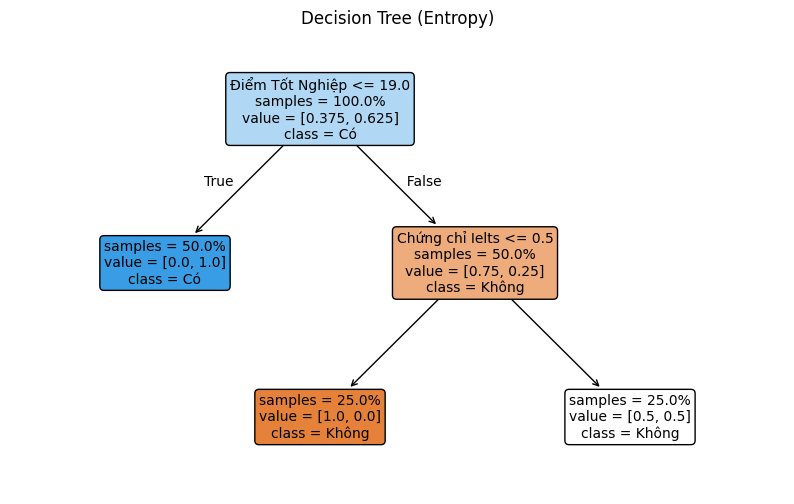

In [ ]:
X = df_encoded[features]
Y = df_encoded['Đậu_ĐH']
clf = DecisionTreeClassifier(criterion='entropy', random_state=0, max_depth=2)
clf.fit(X, Y)
plt.figure(figsize=(10,6))
plot_tree(
    clf,
    feature_names=['Chứng chỉ Ielts', 'Điểm Tốt Nghiệp', 'Cộng Điểm Dân Tộc'],
    class_names=['Không', 'Có'],
    filled=True, rounded=True, proportion=True, impurity=False, fontsize=10
)

plt.title('Decision Tree (Entropy)')
plt.show()

###**6. Test**

In [ ]:
_mapping = {'Có': 0, 'Không': 1}

def encode_input(record):
    return [
        _mapping[record['Chứng_chỉ_Ielts']],
        record['Điểm_Tốt_Nghiệp'],
        _mapping[record['Cộng_Điểm_Dân_Tộc']]
    ]

def predict_pass(record):
    x_list = encode_input(record)
    df_new = pd.DataFrame([x_list], columns=features)
    pred   = clf.predict(df_new)[0]
    return 'Có' if pred == 1 else 'Không'

new_student = {
    'Điểm_Tốt_Nghiệp': 2.0,
    'Chứng_chỉ_Ielts': 'Có',
    'Cộng_Điểm_Dân_Tộc': 'Không'
}
print("Kết quả dự đoán:", predict_pass(new_student))

Kết quả dự đoán: Có


## **7. Demo with Gradio**

In [46]:
import gradio as gr

In [48]:
def predict_and_plot(diem, ielts, dan_toc):
  try:
    record = {
        'Điểm_Tốt_Nghiệp': float(diem),
        'Chứng_chỉ_Ielts': ielts,
        'Cộng_Điểm_Dân_Tộc': dan_toc
    }
    result = predict_pass(record)
    fig, ax = plt.subplots(figsize=(8,6))
    plot_tree(
        clf,
        feature_names = ['Chứng chỉ Ielts', 'Điểm Tốt Nghiệp', 'Cộng Điểm Dân Tộc'],
        class_names = ['Không', 'Có'],
        filled = True, rounded = True, proportion = True, impurity = False, fontsize=8, ax = ax
    )
    ax.set_title('Decision Tree (Entropy)')
    plt.tight_layout()
    return result, fig
  except Exception as e:
    return f"Lỗi nhập liệu: {e}", None

iface = gr.Interface(
    fn=predict_and_plot,
    inputs=[
        gr.Number(
            label="Điểm Tốt Nghiệp",
            value=None,
            placeholder="Ví dụ: 17.0"
        ),
        gr.Radio(
            choices=['Có', 'Không'],
            label="Chứng chỉ IELTS",
            value='Có'
        ),
        gr.Radio(
            choices=['Có', 'Không'],
            label="Cộng Điểm Dân Tộc",
            value='Không'
        ),
    ],
    outputs=[
        gr.Textbox(label="Dự đoán Đậu Đại Học"),
        gr.Plot(label="Decision Tree")
    ],
    title="Demo Student Pass Predictor",
    description="""
**Hướng dẫn nhập liệu**
- **Điểm Tốt Nghiệp**: Nhập số điểm tốt nghiệp (float).
- **Chứng chỉ IELTS**: Chọn `Có` nếu bạn đã có chứng chỉ IELTS, ngược lại chọn `Không`.
- **Cộng Điểm Dân Tộc**: Chọn `Có` nếu bạn được cộng điểm dân tộc, ngược lại chọn `Không`.
Bấm **Run** để xem kết quả dự đoán và cây quyết định.
"""
)

iface.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://4641d75cd9cde5dfdc.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
